<a href="https://colab.research.google.com/github/Asuskf/low-cost-llm-finetuning/blob/main/gpu-memory-benchmark/lab_01_standard_llm_vs_airllm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 01: Standard llm VS airllm 💻


## Description
This lab demonstrates how to run inference for Large Language Models (LLMs), specifically **Platypus2-7B** (7 billion parameters), in resource-constrained environments such as the Google Colab free tier (T4 GPU).

An architectural evaluation is performed, comparing standard loading using the `transformers` library against optimized, low-memory inference via `airllm`.

## Environment and System Requirements ⚙️
The code is designed to run on a T4 GPU.

## 💻 System Resource Usage **Free Colab** (GPU T4)

| Resource        |  Total Capacity |
|----------------|--------------|
| System RAM     |  12.7 GB        |
| GPU RAM        |  15.0 GB        |
| Disk Storage   |  112.6 GB       |

## 🧠 GPU Requirements – [Platypus2-7B](https://huggingface.co/garage-bAInd/Platypus2-7B) (7B parameters)


| Category        | Minimum Requirement                  | Recommended Requirement              |
|-----------------|-------------------------------------|-------------------------------------|
| Model Size      | 7B parameters                       | 7B parameters                       |
| Disk Space      | ~15 GB                              | 20–30 GB                            |
| VRAM (FP16)     | ~13–14 GB                           | 16 GB GPU                           |
| VRAM (8-bit)    | ~8–10 GB                            | 10–12 GB                            |
| VRAM (4-bit)    | ~4–6 GB                             | 6–8 GB                              |
| System RAM      | 16 GB                               | 32 GB                               |
| GPU             | Optional (CPU possible, very slow)  | RTX 3090 / RTX 4090 / A100          |
| CPU             | Modern multi-core                   | 6–8+ cores                          |
| Training HW     | Not feasible on consumer hardware   | A100 80GB                           |
| Context Length  | 4096 tokens                         | 4096 tokens                         |
| Software        | Python, PyTorch, Transformers       | + CUDA, Accelerate                  |

## Dependency Installation 📦
To ensure environment stability and reproducibility, the following specific versions are required:

```bash
pip uninstall -y transformers optimum airllm sentence-transformers
pip install "transformers==4.36.2" "optimum==1.14.0" "airllm==2.6.0" "sentence-transformers==2.6.1" -q

In [1]:
%%shell
pip uninstall -y transformers optimum airllm sentence-transformers
pip install "transformers==4.36.2" "optimum==1.14.0" "airllm==2.6.0" "sentence-transformers==2.6.1" -q

Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: sentence-transformers 5.4.0
Uninstalling sentence-transformers-5.4.0:
  Successfully uninstalled sentence-transformers-5.4.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.8/126.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.9/398.9 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.3/163.3 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 109.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 11.4 MB/s eta 0:00:00


## Without Airllm

In [1]:
from airllm import AutoModel

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


>>>> cache_utils installed


/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [4]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

MODEL_ID = "garage-bAInd/Platypus2-7B"
MAX_LENGTH = 128

# 1. Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

# 2. Modelo (correcto para generación de texto)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto"   # usa GPU si hay
)

# 3. Input
input_text = "I like"

# 4. Tokenización
inputs = tokenizer(
    input_text,
    return_tensors="pt",
    truncation=True,
    max_length=MAX_LENGTH
)

# mover a GPU si existe
inputs = {k: v.to(model.device) for k, v in inputs.items()}

# 5. Generación
output = model.generate(
    **inputs,
    max_new_tokens=20,
    do_sample=True,
    temperature=0.7
)

# 6. Decodificar
result = tokenizer.decode(output[0], skip_special_tokens=True)

print(result)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

I like to think that I’m not an overly sentimental person, but I will be the first


## at the start of the process

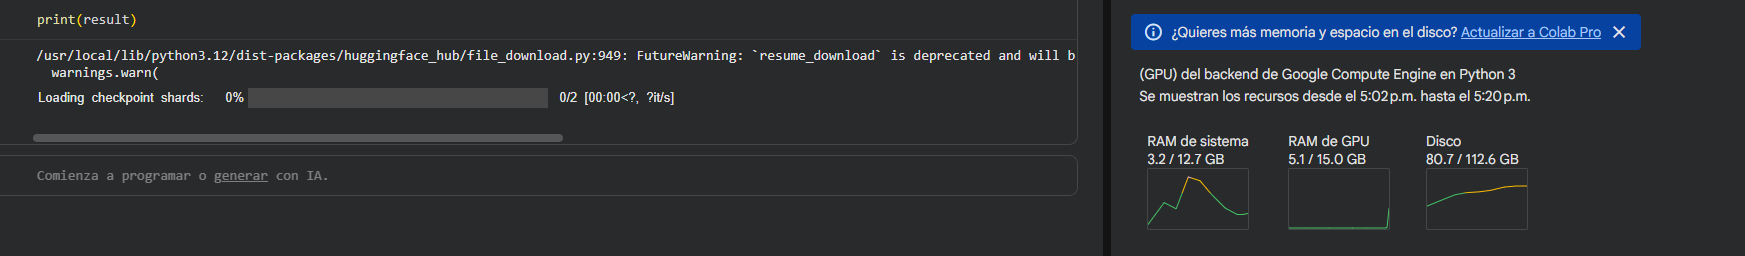

## at the end of the process

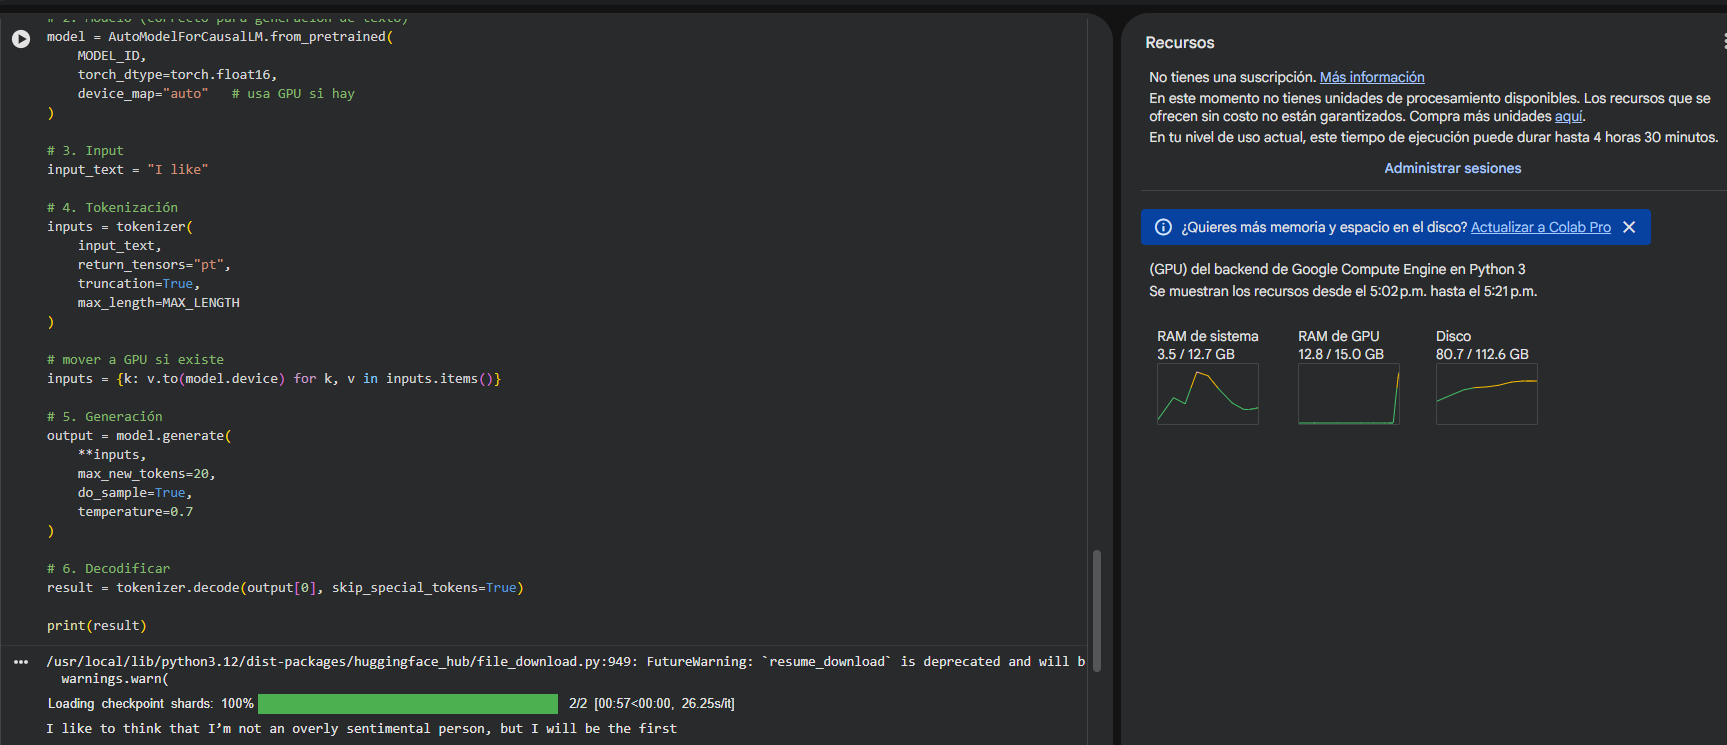

## Airllm

In [2]:
MODEL_ID = "garage-bAInd/Platypus2-7B"
MAX_LENGTH = 128
model = AutoModel.from_pretrained(MODEL_ID, profiling_mode=True)

input_text = [
        #'What is the capital of China?',
        'I like',
    ]

input_tokens = model.tokenizer(input_text,
    return_tensors="pt",
    return_attention_mask=False,
    truncation=True,
    max_length=MAX_LENGTH,
    #padding=True
    )

generation_output = model.generate(
    input_tokens['input_ids'].cuda(),
    max_new_tokens=20,
    use_cache=True,
    return_dict_in_generate=True)

model.tokenizer.decode(generation_output.sequences[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

saved layers already found in /root/.cache/huggingface/hub/models--garage-bAInd--Platypus2-7B/snapshots/6530478f705b1a4e0d81b844148ddc237edfe1dd/splitted_model


The BetterTransformer implementation does not support padding during training, as the fused kernels do not support attention masks. Beware that passing padded batched data during training may result in unexpected outputs. Please refer to https://huggingface.co/docs/optimum/bettertransformer/overview for more details.
The BetterTransformer implementation does not support padding during training, as the fused kernels do not support attention masks. Beware that passing padded batched data during training may result in unexpected outputs. Please refer to https://huggingface.co/docs/optimum/bettertransformer/overview for more details.
cuda:0: 100%|██████████| 35/35 [01:00<00:00,  1.74s/it]


total time for load_safe_tensor: 1.6390138252956596
total time for compression_time: 0.0005883589999946537
total time for pin_memory_to_trigger_load: 54.16614484786987
total time for load_safe_tensor_cpu_wait: 40.21140766143799
total time for create_layer_from_state_dict: 3.4879934787750244
total time for kick_off_load_cpu: 0.0018777847290039062
total infer process time(including all above plus gpu compute): 24.3050
total infer wall time(including all above plus gpu compute): 61.4784


...

The BetterTransformer implementation does not support padding during training, as the fused kernels do not support attention masks. Beware that passing padded batched data during training may result in unexpected outputs. Please refer to https://huggingface.co/docs/optimum/bettertransformer/overview for more details.
cuda:0: 100%|██████████| 35/35 [00:58<00:00,  1.66s/it]


total time for load_safe_tensor: 2.0315882703055763
total time for compression_time: 0.000717923999843606
total time for pin_memory_to_trigger_load: 51.34472441673279
total time for load_safe_tensor_cpu_wait: 41.17383575439453
total time for create_layer_from_state_dict: 3.1334288120269775
total time for kick_off_load_cpu: 0.0017347335815429688
total infer process time(including all above plus gpu compute): 23.1154
total infer wall time(including all above plus gpu compute): 58.8108


The BetterTransformer implementation does not support padding during training, as the fused kernels do not support attention masks. Beware that passing padded batched data during training may result in unexpected outputs. Please refer to https://huggingface.co/docs/optimum/bettertransformer/overview for more details.
cuda:0: 100%|██████████| 35/35 [00:56<00:00,  1.63s/it]

total time for load_safe_tensor: 1.290310735488788
total time for compression_time: 0.00048530599985951994
total time for pin_memory_to_trigger_load: 51.39421081542969
total time for load_safe_tensor_cpu_wait: 39.89459466934204
total time for create_layer_from_state_dict: 3.162064552307129
total time for kick_off_load_cpu: 0.0017478466033935547
total infer process time(including all above plus gpu compute): 23.1959
total infer wall time(including all above plus gpu compute): 57.6575


'<s> I like to think of myself as a pretty good cook. I can make a mean chicken pot pie,'

## at the end of the process

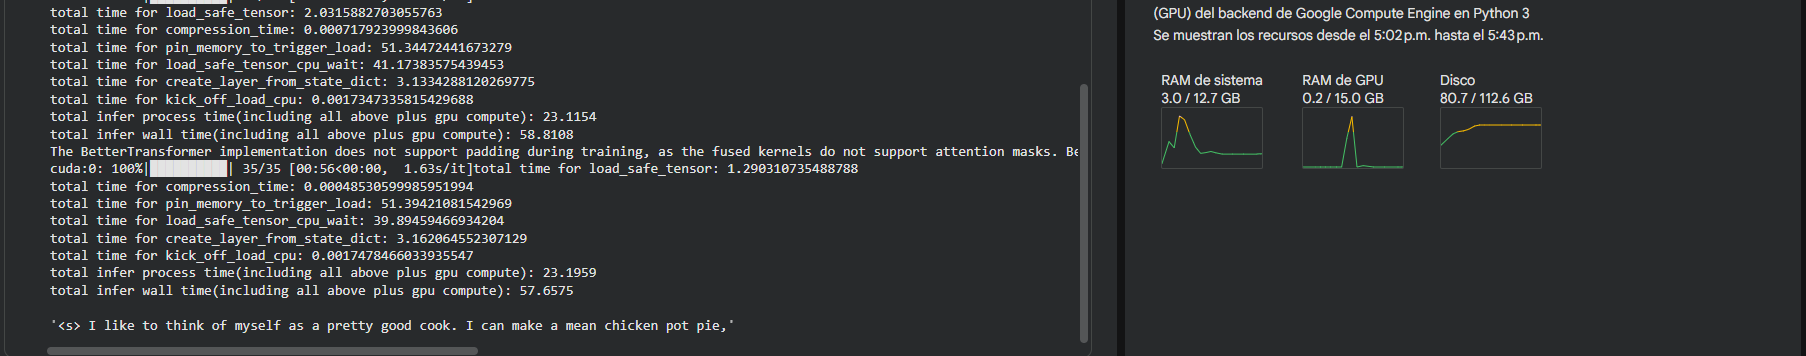